In [2]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [7]:
file_path = r"C:\Users\User\OneDrive - Emory University\Documents\GitHub\BIOS-584\Final Project - Josie\Continuous.xlsx"
data = pd.read_excel(file_path)  

In [13]:
corr_steak, pval_steak = spearmanr(data['VB'], data['STEAK'], nan_policy='omit')
corr_age, pval_age = spearmanr(data['VB'], data['AGE'], nan_policy='omit')

print(f"{corr_steak:.3f}, {pval_steak:.3f}")
print(f"{corr_age:.3f}, {pval_age:.3f}")

0.139, 0.044
0.338, 0.000


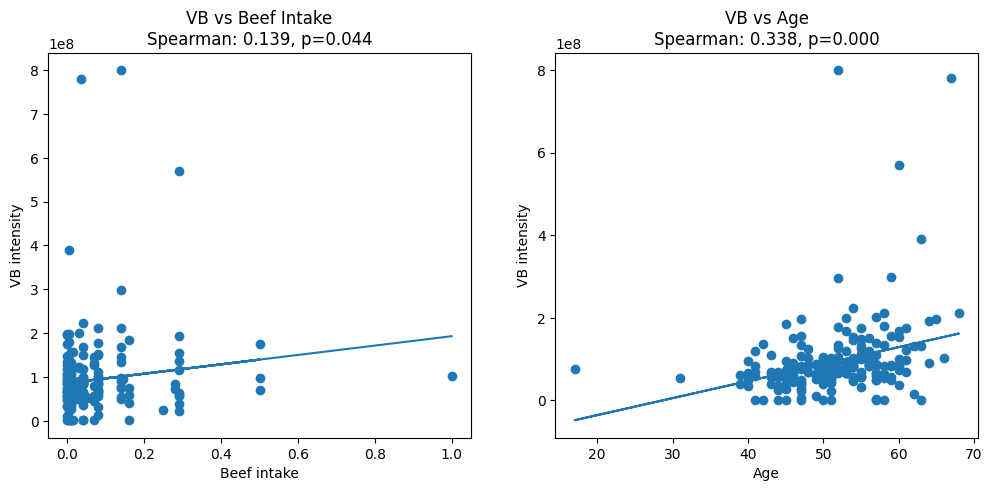

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(data['STEAK'], data['VB'])
X = sm.add_constant(data['STEAK'])
model = sm.OLS(data['VB'], X, missing='drop').fit()
axes[0].plot(data['STEAK'], model.predict(X))
axes[0].set_xlabel('Beef intake')
axes[0].set_ylabel('VB intensity')
axes[0].set_title(f'VB vs Beef Intake\nSpearman: {corr_steak:.3f}, p={pval_steak:.3f}')

axes[1].scatter(data['AGE'], data['VB'])
X = sm.add_constant(data['AGE'])
model = sm.OLS(data['VB'], X, missing='drop').fit()
axes[1].plot(data['AGE'], model.predict(X))
axes[1].set_xlabel('Age')
axes[1].set_ylabel('VB intensity')
axes[1].set_title(f'VB vs Age\nSpearman: {corr_age:.3f}, p={pval_age:.3f}')

plt.show()